# processing large ensembles

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
# import matplotlib.pyplot as plt
# from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
# import matplotlib as mpl
# import matplotlib.ticker as mticker
import netCDF4
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.util import add_cyclic_point
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
# from dask.distributed import Client
# client = Client(n_workers=4, threads_per_worker=2)
# client

In [4]:
from scipy import stats

In [5]:
# mpl.rcParams['font.family'] = 'Droid Sans'
# mpl.rcParams['font.size'] = 12
# # Edit axes parameters
# mpl.rcParams['axes.linewidth'] = 1.5
# # Tick properties
# mpl.rcParams['xtick.major.size'] = 5
# mpl.rcParams['xtick.minor.size'] = 3
# mpl.rcParams['xtick.major.width'] = 1
# mpl.rcParams['xtick.direction'] = 'out'
# mpl.rcParams['ytick.major.size'] = 5
# mpl.rcParams['ytick.minor.size'] = 3
# mpl.rcParams['ytick.major.width'] = 1
# mpl.rcParams['ytick.direction'] = 'out'

### Functions needed for the analysis

In [6]:
from functions import preproc_funcs as funcs

In [7]:
from functions import xr_lowess

In [8]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [9]:
import glob
import multiprocessing as mp

In [10]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = sorted(glob.glob(pattern))
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        # model_identifier = path_parts[6] + '_' + path_parts[8][:-1]
        model_identifier = path_parts[8] + '_' + path_parts[10][:-1]
        if model_identifier not in model_files:
            model_files[model_identifier] = '/'.join(path_parts[:-1]) + '/*.nc'  # Store only the first file for each model
    return model_files

## find the files for a single model

In [11]:
model = 'ACCESS-ESM1-5'

In [12]:
ts_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/ts/gn/*/*.nc'
ts_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/ts/gn/*/*.nc'


In [13]:
co2_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/co2/gn/*/*.nc'
co2_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/co2/gn/*/*.nc'

In [14]:
pr_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/pr/gn/*/*.nc'
pr_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/pr/gn/*/*.nc'

In [15]:
psl_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/psl/gn/*/*.nc'
psl_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/psl/gn/*/*.nc'

In [16]:
uas_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/uas/gn/*/*.nc'
uas_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/uas/gn/*/*.nc'

In [17]:
vas_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/vas/gn/*/*.nc'
vas_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/vas/gn/*/*.nc'

In [18]:
tauu_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Amon/tauu/gn/*/*.nc'
tauu_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Amon/tauu/gn/*/*.nc'

In [19]:
thetao_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/thetao/gn/*/*.nc'
thetao_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/thetao/gn/*/*.nc'

In [20]:
msftbarot_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/msftbarot/gn/*/*.nc'
msftbarot_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/msftbarot/gn/*/*.nc'

In [21]:
msftmz_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/msftmz/gn/*/*.nc'
msftmz_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/msftmz/gn/*/*.nc'

In [22]:
htovovrt_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/htovovrt/gn/*/*.nc'
htovovrt_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/htovovrt/gn/*/*.nc'

In [23]:
htovgyre_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/Omon/htovgyre/gn/*/*.nc'
htovgyre_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/Omon/htovgyre/gn/*/*.nc'

In [24]:
siextentn_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/SImon/siextentn/gn/*/*.nc'
siextentn_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/SImon/siextentn/gn/*/*.nc'

In [25]:
siextents_pattern_hist = f'/g/data/*/*/CMIP6/CMIP/*/{model}/esm-hist/*/SImon/siextents/gn/*/*.nc'
siextents_pattern_ssp5 = f'/g/data/*/*/CMIP6/C4MIP/*/{model}/esm-ssp585/*/SImon/siextents/gn/*/*.nc'

In [26]:
ts_files_hist = find_all_files(ts_pattern_hist)
ts_files_ssp5 = find_all_files(ts_pattern_ssp5)

In [27]:
co2_files_hist = find_all_files(co2_pattern_hist)
co2_files_ssp5 = find_all_files(co2_pattern_ssp5)

In [28]:
pr_files_hist = find_all_files(pr_pattern_hist)
pr_files_ssp5 = find_all_files(pr_pattern_ssp5)

In [29]:
psl_files_hist = find_all_files(psl_pattern_hist)
psl_files_ssp5 = find_all_files(psl_pattern_ssp5)

In [30]:
uas_files_hist = find_all_files(uas_pattern_hist)
uas_files_ssp5 = find_all_files(uas_pattern_ssp5)

In [31]:
vas_files_hist = find_all_files(vas_pattern_hist)
vas_files_ssp5 = find_all_files(vas_pattern_ssp5)

In [32]:
tauu_files_hist = find_all_files(tauu_pattern_hist)
tauu_files_ssp5 = find_all_files(tauu_pattern_ssp5)

In [33]:
thetao_files_hist = find_all_files(thetao_pattern_hist)
thetao_files_ssp5 = find_all_files(thetao_pattern_ssp5)

In [34]:
msftbarot_files_hist = find_all_files(msftbarot_pattern_hist)
msftbarot_files_ssp5 = find_all_files(msftbarot_pattern_ssp5)

In [35]:
msftmz_files_hist = find_all_files(msftmz_pattern_hist)
msftmz_files_ssp5 = find_all_files(msftmz_pattern_ssp5)

In [36]:
htovovrt_files_hist = find_all_files(htovovrt_pattern_hist)
htovovrt_files_ssp5 = find_all_files(htovovrt_pattern_ssp5)

In [37]:
htovgyre_files_hist = find_all_files(htovgyre_pattern_hist)
htovgyre_files_ssp5 = find_all_files(htovgyre_pattern_ssp5)

In [38]:
siextentn_files_hist = find_all_files(siextentn_pattern_hist)
siextentn_files_ssp5 = find_all_files(siextentn_pattern_ssp5)

In [39]:
siextents_files_hist = find_all_files(siextents_pattern_hist)
siextents_files_ssp5 = find_all_files(siextents_pattern_ssp5)

In [40]:
import xesmf as xe

In [41]:
# temp_hist = xr.open_dataset(ts_files_hist['ACCESS-CM2'])
# temp_hist

In [42]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset>
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 -90.0 -88.5 -88.5 ... 88.5 90.0

In [43]:
from dask.diagnostics import ProgressBar

In [44]:
# global_regridder = xe.Regridder(xc.open_mfdataset(uas_files_hist['ACCESS-ESM1-5_r10i1p1f']).load(), ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
# global_regridder

In [45]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # Load datasets
        var_file_hist = siextentn_files_hist[model_identifier] # change here
        var_file_ssp = siextentn_files_ssp5[model_identifier] # change here
        ds_var_hist = xc.open_mfdataset(var_file_hist, use_cftime=True).sel(time = slice('1850-01-01', '2015-01-01'))
        ds_var_ssp = xc.open_mfdataset(var_file_ssp, use_cftime=True)
        # add custom time ranges
        ds_var_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_var_ssp.time.dt.year[-1])
        ds_var_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        combined = xr.concat([ds_var_hist, ds_var_ssp], dim='time')
        # regridder = xe.Regridder(combined, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        #
        # with ProgressBar():
        # var = regridder(combined.msftmz.resample(time = 'AS-JUN').mean('time')).load()  # change here
        var = (combined.siextentn.resample(time = 'AS-JUN').mean('time')).load()  # change here
        return model_identifier, var
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")


In [51]:
models_to_process = [(model) for model in siextentn_files_hist if model in siextentn_files_ssp5]
models_to_process

['ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r2i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r9i1p1f']

In [47]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [ ]:
# Run multiprocessing and gather results
res_arr = []
# with mp.Pool(processes=mp.cpu_count()) as pool:
with mp.Pool(processes=4) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [ ]:
model_list = np.array(res_arr)[:, 0]
model_list

array(['ACCESS-ESM1-5_r10i1p1f', 'ACCESS-ESM1-5_r1i1p1f',
       'ACCESS-ESM1-5_r2i1p1f', 'ACCESS-ESM1-5_r3i1p1f',
       'ACCESS-ESM1-5_r4i1p1f', 'ACCESS-ESM1-5_r5i1p1f',
       'ACCESS-ESM1-5_r6i1p1f', 'ACCESS-ESM1-5_r7i1p1f',
       'ACCESS-ESM1-5_r8i1p1f', 'ACCESS-ESM1-5_r9i1p1f'], dtype=object)

In [185]:
res_arr

[('ACCESS-ESM1-5_r10i1p1f',
  <xarray.DataArray 'siextentn' (time: 252)>
  array([15.771398 , 12.70216  , 13.371838 , 13.714352 , 12.889226 ,
         13.101571 , 12.90524  , 12.364826 , 11.886559 , 11.928384 ,
         12.032322 , 12.260619 , 12.457271 , 12.310837 , 11.947467 ,
         12.044578 , 12.053786 , 12.069362 , 12.001332 , 12.28605  ,
         12.833257 , 12.660628 , 12.8079405, 12.206784 , 12.111104 ,
         12.073813 , 12.005105 , 11.548264 , 11.768754 , 11.504082 ,
         11.961907 , 11.874846 , 11.87062  , 11.419599 , 11.678097 ,
         12.149658 , 12.1864195, 12.221508 , 11.697208 , 11.771409 ,
         12.059894 , 11.994893 , 12.416058 , 12.366936 , 12.568417 ,
         12.36684  , 12.6142645, 12.462302 , 12.209907 , 12.037647 ,
         12.058232 , 11.983966 , 12.205426 , 12.08468  , 12.397041 ,
         12.595618 , 12.58586  , 12.116226 , 12.684894 , 12.503822 ,
         12.284787 , 12.329357 , 12.172329 , 12.1192465, 12.064259 ,
         12.00747  , 12.101901

In [186]:
model_var = xr.concat(np.array(res_arr)[:, 1], dim=model_list, coords='minimal', compat='override').rename(dict(concat_dim = 'model')).to_dataset(name = 'siextentn')

In [187]:
out = xr.merge([model_var])
out

<xarray.Dataset>
Dimensions:    (time: 252, model: 10)
Coordinates:
  * time       (time) object 1849-06-01 00:00:00 ... 2100-06-01 00:00:00
  * model      (model) object 'ACCESS-ESM1-5_r10i1p1f' ... 'ACCESS-ESM1-5_r9i...
Data variables:
    siextentn  (model, time) float32 15.77 12.7 13.37 ... 3.466 3.28 0.8703

In [188]:
out.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/{model}_ssp5_siextentn.nc')

### run for thetao and processing isotherm data

In [44]:
from dask.distributed import Client

In [85]:
client = Client(threads_per_worker=2)
# client.amm.start()
client

2025-09-24 20:16:38,735 [INFO]: scheduler.py(__init__:1615) >> State start
2025-09-24 20:16:38,848 [INFO]: scheduler.py(start_unsafe:3860) >>   Scheduler at:     tcp://127.0.0.1:32989
2025-09-24 20:16:38,849 [INFO]: scheduler.py(start_unsafe:3862) >>   dashboard at:           127.0.0.1:46751
2025-09-24 20:16:38,931 [INFO]: core.py(handle_stream:877) >> Connection to tcp://127.0.0.1:35996 has been closed.
2025-09-24 20:16:38,932 [INFO]: scheduler.py(remove_client:5272) >> Remove client Client-worker-5b6639d8-992c-11f0-a362-00000391fe80
2025-09-24 20:16:38,932 [INFO]: core.py(handle_stream:877) >> Connection to tcp://127.0.0.1:34808 has been closed.
2025-09-24 20:16:38,933 [INFO]: scheduler.py(remove_worker:4795) >> Remove worker <WorkerState 'tcp://127.0.0.1:36145', name: 1, status: running, memory: 0, processing: 0>
2025-09-24 20:16:38,934 [INFO]: core.py(remove:1480) >> Removing comms to tcp://127.0.0.1:36145
2025-09-24 20:16:38,938 [INFO]: scheduler.py(add_client:5264) >> Close clien

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46751/status,
Dashboard: http://127.0.0.1:46751/status,Workers: 7
Total threads: 14,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32989,Workers: 7
Dashboard: http://127.0.0.1:46751/status,Total threads: 14
Started: Just now,Total memory: 125.19 GiB
Comm: tcp://127.0.0.1:43301,Total threads: 2
Dashboard: http://127.0.0.1:46565/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:38809,


2025-09-24 20:17:05,686 - distributed.nanny - WARNING - Worker process still alive after 3.1999966430664064 seconds, killing
2025-09-24 20:17:05,686 [WARNING]: nanny.py(kill:836) >> Worker process still alive after 3.1999966430664064 seconds, killing
2025-09-24 20:17:05,805 [INFO]: nanny.py(mark_stopped:761) >> Worker process 435046 was killed by signal 9


In [46]:
sample = xr.open_mfdataset(thetao_files_hist['ACCESS-ESM1-5_r10i1p1f'], parallel=True)
sample

<xarray.Dataset>
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12...
  * lev                 (lev) float64 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * i                   (i) int32 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    latitude            (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] dask.array<chunksize=(120, 2), meta=np.ndarray>
    lev_bnds            (time, lev, bnds) float64 dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 dask.array<chunksize=(120, 300, 360, 4), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 dask.array<chunksize=(120, 300, 360, 4), meta=np.ndarray>
    thetao              (time, lev, j, i) float32 dask.array<chunksize=(120, 50, 300, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  91311.0
    creation_date:          2020-07-30T04:35:15Z
    ...                     ...
    variable_id:            thetao
    variant_label:          r10i1p1f1
    version:                v20200730
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5fc74efd-f9f1-416b-a2d5-e664de7afe60

In [194]:
regridder = xe.Regridder(sample, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [135]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = sample['latitude']  # shape: (i, j)
lon = sample['longitude']

# Define your region
lat_min, lat_max = -5, 5
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

custom_mask = ((lat >= lat_min) & (lat <= lat_max))

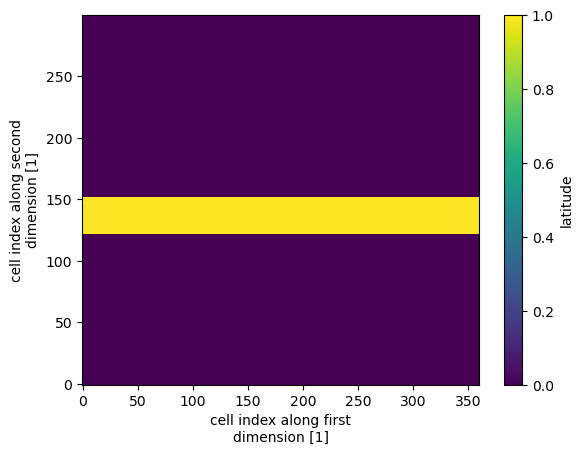

In [136]:
custom_mask.plot()

In [117]:
from functools import partial

In [ ]:
def _preprocess(x, mask):
    return x.where(mask, drop=True).sel(lev=slice(0, 350))#.resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [ ]:
def process_model_for_thetao(model_identifier, outdir="/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_so/"):
    # Hist
    var_file_hist = thetao_files_hist[model_identifier]
    ds_var_hist = (
        xr.open_mfdataset(
            var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
            chunks=dict(time=-1, lev=-1, i=-1, j=-1),
            data_vars=["thetao"], coords="minimal", compat="override", join="override"
        ).thetao
    )

    # SSP5
    var_file_ssp = thetao_files_ssp5[model_identifier]
    ds_var_ssp = (
        xr.open_mfdataset(
            var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
            chunks=dict(time=-1, lev=-1, i=-1, j=-1),
            data_vars=["thetao"], coords="minimal", compat="override", join="override"
        ).thetao
    )

    # Lazy concat
    combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time").resample(time = 'AS-JUN').mean('time')#.load()
    outpath = f"{outdir}/{model_identifier}.zarr"
    combined.to_dataset(name='thetao').to_zarr(outpath, mode='w')
    return outpath

In [131]:
models_to_process = [(model) for model in thetao_files_hist if model in thetao_files_ssp5]
models_to_process

['ACCESS-ESM1-5_r10i1p1f',
 'ACCESS-ESM1-5_r1i1p1f',
 'ACCESS-ESM1-5_r2i1p1f',
 'ACCESS-ESM1-5_r3i1p1f',
 'ACCESS-ESM1-5_r4i1p1f',
 'ACCESS-ESM1-5_r5i1p1f',
 'ACCESS-ESM1-5_r6i1p1f',
 'ACCESS-ESM1-5_r7i1p1f',
 'ACCESS-ESM1-5_r8i1p1f',
 'ACCESS-ESM1-5_r9i1p1f']

In [132]:
# res_arr = []

# for i, model_identifier in enumerate(models_to_process):
#     _, out = process_model(models_to_process[i])
#     res_arr.append((model_identifier, out))
#     print(f'Completed {i+1}')

In [ ]:
res_arr = []
for i, model in enumerate(models_to_process):
    zarr_path = process_model_for_thetao(model)
    res_arr.append(zarr_path)
    print(f"Completed {i+1}/{len(models_to_process)} -> saved to {zarr_path}", end="\r")

In [ ]:
# import glob
# files = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao/*.zarr')

# datasets = [xr.open_zarr(f) for f in files]
# # Combine lazily along new model dimension
# combined = xr.concat([ds['thetao'] for ds in datasets], dim="model")

In [129]:
# combined.sel(time = slice('1850', '1900')).mean(('time', 'j', 'model')).plot(cmap=cmocean.cm.balance, vmin=10, vmax=30)
# combined.sel(time = slice('1850', '1900')).mean(('time', 'j', 'model')).plot.contour(cmap=cmocean.cm.balance, levels=[20])
# plt.gca().invert_yaxis()

### cross-section and side view thetao values

In [137]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = sample['latitude']  # shape: (i, j)
lon = sample['longitude']

# Define your region
lat_min, lat_max = -80, -40
lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

custom_mask = ((lat >= lat_min) & (lat <= lat_max))

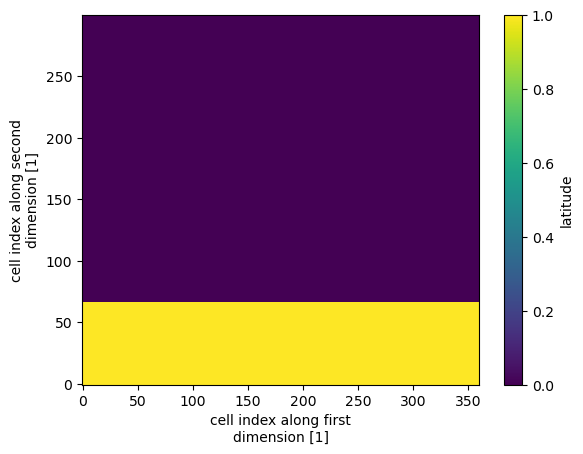

In [138]:
custom_mask.plot()

In [139]:
from functools import partial

In [ ]:
def _preprocess(x, mask):
    return x.where(mask, drop=True).sel(lev=slice(0, 2000))#.resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [197]:
model_identifier = models_to_process[0]
model_identifier

'ACCESS-ESM1-5_r10i1p1f'

In [ ]:

var_file_hist = thetao_files_hist[model_identifier]
ds_var_hist = (
    xr.open_mfdataset(
        var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)

In [156]:
ds_var_hist

<xarray.DataArray 'thetao' (time: 1980, lev: 36, j: 67, i: 360)>
dask.array<concatenate, shape=(1980, 36, 67, 360), dtype=float32, chunksize=(120, 36, 67, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lev        (lev) float64 5.0 15.0 25.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j          (j) int32 0 1 2 3 4 5 6 7 8 9 ... 57 58 59 60 61 62 63 64 65 66
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 -77.88 -77.88 -77.88 ... -40.38 -40.38 -40.38
    longitude  (j, i) float64 80.5 81.5 82.5 83.5 84.5 ... 76.5 77.5 78.5 79.5
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        Diagnostic should be contributed even for models using co...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    history:        2020-07-30T04:35:12Z altered by CMOR: replaced missing va...

In [157]:

# SSP5
var_file_ssp = thetao_files_ssp5[model_identifier]
ds_var_ssp = (
    xr.open_mfdataset(
        var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)


In [158]:
# Lazy concat
combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time")#.load()

In [160]:
thetao_so = combined.resample(time = 'AS-JUN').mean('time').load()

In [162]:
thetao_so.to_dataset(name='thetao').to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_so/thetao_so_trans_r10.nc')

In [163]:
# # Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
# lat = sample['latitude']  # shape: (i, j)
# lon = sample['longitude']

# # Define your region
# lat_min, lat_max = -80, -40
# lon_min, lon_max = 100, 300

# # Build a mask for where lat/lon fall within the box
# # custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
# #               (lon >= lon_min) & (lon <= lon_max))

# custom_mask = ((lat >= lat_min) & (lat <= lat_max))

In [164]:
# custom_mask.plot()

In [165]:
from functools import partial

In [204]:
def _preprocess(x, mask):
    return x.sel(lev=slice(0, 2000))#.resample(time = 'AS-JUN').mean('time')

partial_func = partial(_preprocess, mask=custom_mask)

In [205]:
model_identifier = models_to_process[0]
model_identifier

'ACCESS-ESM1-5_r10i1p1f'

In [206]:

var_file_hist = thetao_files_hist[model_identifier]
ds_var_hist = (
    xr.open_mfdataset(
        var_file_hist, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=90),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)

In [207]:
ds_var_hist

<xarray.DataArray 'thetao' (time: 1980, lev: 36, j: 300, i: 360)>
dask.array<concatenate, shape=(1980, 36, 300, 360), dtype=float32, chunksize=(120, 36, 90, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lev        (lev) float64 5.0 15.0 25.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        Diagnostic should be contributed even for models using co...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello
    history:        2020-07-30T04:35:12Z altered by CMOR: replaced missing va...

In [208]:

# SSP5
var_file_ssp = thetao_files_ssp5[model_identifier]
ds_var_ssp = (
    xr.open_mfdataset(
        var_file_ssp, use_cftime=True, parallel=True, preprocess=partial_func,
        chunks=dict(time=-1, lev=-1, i=-1, j=-1),
        data_vars=["thetao"], coords="minimal", compat="override", join="override"
    ).thetao
)


In [209]:
# Lazy concat
combined = xr.concat([ds_var_hist, ds_var_ssp], dim="time")#.load()

In [211]:
thetao_zonal = combined.resample(time = 'AS-JUN').mean('time').mean('i').load()

In [212]:
thetao_zonal.to_dataset(name='thetao').to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_lens/thetao_zonal/thetao_zonal_trans_r10.nc')

In [214]:
thetao_zonal

<xarray.DataArray 'thetao' (time: 252, lev: 36, j: 300)>
array([[[        nan, -1.6154453 , -1.5342916 , ..., -1.7129434 ,
         -1.7106678 , -1.7059964 ],
        [        nan, -1.6288234 , -1.5695149 , ..., -1.7141683 ,
         -1.7118527 , -1.7075018 ],
        [        nan, -1.656011  , -1.6110792 , ..., -1.7153057 ,
         -1.7129503 , -1.7088045 ],
        ...,
        [        nan,         nan,         nan, ..., -0.585654  ,
         -0.5890004 , -0.59194064],
        [        nan,         nan,         nan, ..., -0.6074667 ,
         -0.611016  , -0.6116457 ],
        [        nan,         nan,         nan, ..., -0.63249403,
         -0.6339609 , -0.6359188 ]],

       [[        nan, -1.452658  , -1.4985379 , ..., -1.2702024 ,
         -1.2799987 , -1.2656325 ],
        [        nan, -1.5111833 , -1.5612712 , ..., -1.3715655 ,
         -1.3739002 , -1.3603352 ],
        [        nan, -1.5757155 , -1.6230018 , ..., -1.4882315 ,
         -1.4849086 , -1.4740585 ],
...
        [        nan,         nan,         nan, ...,  0.18216121,
          0.18432878,  0.18561853],
        [        nan,         nan,         nan, ..., -0.0599592 ,
         -0.05969981, -0.05086387],
        [        nan,         nan,         nan, ..., -0.23267382,
         -0.23397723, -0.2283296 ]],

       [[        nan, -1.4619166 , -1.4834775 , ...,  4.6795545 ,
          4.64628   ,  4.666546  ],
        [        nan, -1.5926588 , -1.6349182 , ...,  3.8124697 ,
          3.766077  ,  3.778912  ],
        [        nan, -1.6980983 , -1.7313137 , ...,  2.5212412 ,
          2.4624329 ,  2.4559472 ],
        ...,
        [        nan,         nan,         nan, ...,  0.17890723,
          0.18349075,  0.1845912 ],
        [        nan,         nan,         nan, ..., -0.06511056,
         -0.06351776, -0.05490663],
        [        nan,         nan,         nan, ..., -0.2373814 ,
         -0.23800981, -0.23462614]]], dtype=float32)
Coordinates:
  * lev      (lev) float64 5.0 15.0 25.0 35.0 ... 1.623e+03 1.802e+03 1.985e+03
  * j        (j) int32 0 1 2 3 4 5 6 7 8 ... 291 292 293 294 295 296 297 298 299
  * time     (time) object 1849-06-01 00:00:00 ... 2100-06-01 00:00:00